# 03 Check WLASL1000 Keypoint Output

## Purpose
This notebook validates extracted WLASL1000 keypoint files and creates the final clean training index.

## Main output

```text
data/processed/ASL/WLASL1000/wlasl1000_clean_keypoint_index.csv
```

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
PROJECT_ROOT = Path("E:/Be_My_Ear")
DATASET_NAME = "WLASL1000"
PREFIX = "wlasl1000"

BASE_DIR = PROJECT_ROOT / "data" / "processed" / "ASL" / DATASET_NAME
KEYPOINT_DIR = BASE_DIR / "keypoints"

VIDEO_INDEX_FILE = BASE_DIR / f"{PREFIX}_video_index.csv"
KEYPOINT_INDEX_FILE = BASE_DIR / f"{PREFIX}_keypoint_index.csv"
CLEAN_INDEX_FILE = BASE_DIR / f"{PREFIX}_clean_keypoint_index.csv"

video_df = pd.read_csv(VIDEO_INDEX_FILE)

print("Videos in usable index:", len(video_df))
print("Classes:", video_df["label_id"].nunique())
print("Extracted .npy files:", len(list(KEYPOINT_DIR.glob("*.npy"))))

Videos in usable index: 7232
Classes: 1000
Extracted .npy files: 7232


## 1. Rebuild keypoint index

In [4]:
records = []

for _, row in video_df.iterrows():
    keypoint_path = KEYPOINT_DIR / f"{row['video_id']}.npy"

    if keypoint_path.exists():
        records.append({
            "video_id": row["video_id"],
            "gloss": row["gloss"],
            "label_id": int(row["label_id"]),
            "original_class_id": int(row["original_class_id"]),
            "video_path": row["video_path"],
            "keypoint_path": str(keypoint_path)
        })

keypoint_df = pd.DataFrame(records)
keypoint_df.to_csv(KEYPOINT_INDEX_FILE, index=False)

print("Saved keypoint index:", KEYPOINT_INDEX_FILE)
print("Keypoint samples:", len(keypoint_df))
print("Classes:", keypoint_df["label_id"].nunique())

keypoint_df.head()

Saved keypoint index: E:\Be_My_Ear\data\processed\ASL\WLASL1000\wlasl1000_keypoint_index.csv
Keypoint samples: 7232
Classes: 1000


,video_id,gloss,label_id,original_class_id,video_path,keypoint_path
0,65097,art,44,481,E:\Be_My_Ear\data\raw\ASL\videos\65097.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL1000\keyp...
1,24029,game,397,208,E:\Be_My_Ear\data\raw\ASL\videos\24029.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL1000\keyp...
2,55292,structure,867,998,E:\Be_My_Ear\data\raw\ASL\videos\55292.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL1000\keyp...
3,2108,alone,20,352,E:\Be_My_Ear\data\raw\ASL\videos\02108.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL1000\keyp...
4,2109,alone,20,352,E:\Be_My_Ear\data\raw\ASL\videos\02109.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL1000\keyp...


## 2. Check missing files

In [5]:
expected_ids = set(video_df["video_id"].astype(str))
actual_ids = set([p.stem for p in KEYPOINT_DIR.glob("*.npy")])

missing = expected_ids - actual_ids

print("Missing keypoint files:", len(missing))
list(missing)[:20]

Missing keypoint files: 0


[]

## 3. Check shape and zero ratio

In [6]:
shape_records = []

for _, row in keypoint_df.iterrows():
    arr = np.load(row["keypoint_path"])

    shape_records.append({
        "video_id": row["video_id"],
        "gloss": row["gloss"],
        "label_id": row["label_id"],
        "shape": arr.shape,
        "num_frames": arr.shape[0],
        "num_features": arr.shape[1] if len(arr.shape) == 2 else None,
        "zero_ratio": float(np.mean(arr == 0))
    })

shape_df = pd.DataFrame(shape_records)

print("Unique shapes:")
print(shape_df["shape"].value_counts())

bad_shapes = shape_df[(shape_df["num_frames"] != 60) | (shape_df["num_features"] != 258)]

print("Bad shape files:", len(bad_shapes))
print("\nZero ratio summary:")
print(shape_df["zero_ratio"].describe())

shape_df.sort_values("zero_ratio", ascending=False).head(20)

Unique shapes:
shape
(60, 258)    7232
Name: count, dtype: int64
Bad shape files: 0

Zero ratio summary:
count    7232.000000
mean        0.237739
std         0.112566
min         0.000000
25%         0.162791
50%         0.256783
75%         0.325581
max         0.522481
Name: zero_ratio, dtype: float64


,video_id,gloss,label_id,shape,num_frames,num_features,zero_ratio
6235,53449,sour,836,"(60, 258)",60,258,0.522481
2415,6436,bitter,103,"(60, 258)",60,258,0.522481
6932,63237,who,973,"(60, 258)",60,258,0.501357
155,31901,know,511,"(60, 258)",60,258,0.488760
6933,63236,who,973,"(60, 258)",60,258,0.488760
4566,19685,europe,329,"(60, 258)",60,258,0.484302
5061,28736,if,475,"(60, 258)",60,258,0.484302
639,55661,sugar,873,"(60, 258)",60,258,0.476550
3226,37839,neck,602,"(60, 258)",60,258,0.476550
6331,21209,father,354,"(60, 258)",60,258,0.472481


## 4. Create clean index

In [7]:
valid_ids = set(
    shape_df[
        (shape_df["num_frames"] == 60) &
        (shape_df["num_features"] == 258) &
        (shape_df["zero_ratio"] < 0.95)
    ]["video_id"].astype(str)
)

clean_df = keypoint_df[keypoint_df["video_id"].astype(str).isin(valid_ids)].copy()

zero_lookup = shape_df.set_index(shape_df["video_id"].astype(str))["zero_ratio"].to_dict()
clean_df["zero_ratio"] = clean_df["video_id"].astype(str).map(zero_lookup)

clean_df.to_csv(CLEAN_INDEX_FILE, index=False)

print("Saved clean index:", CLEAN_INDEX_FILE)
print("Clean samples:", len(clean_df))
print("Clean classes:", clean_df["label_id"].nunique())

clean_df.head()

Saved clean index: E:\Be_My_Ear\data\processed\ASL\WLASL1000\wlasl1000_clean_keypoint_index.csv
Clean samples: 7232
Clean classes: 1000


,video_id,gloss,label_id,original_class_id,video_path,keypoint_path,zero_ratio
0,65097,art,44,481,E:\Be_My_Ear\data\raw\ASL\videos\65097.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL1000\keyp...,0.305233
1,24029,game,397,208,E:\Be_My_Ear\data\raw\ASL\videos\24029.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL1000\keyp...,0.016667
2,55292,structure,867,998,E:\Be_My_Ear\data\raw\ASL\videos\55292.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL1000\keyp...,0.159109
3,2108,alone,20,352,E:\Be_My_Ear\data\raw\ASL\videos\02108.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL1000\keyp...,0.281977
4,2109,alone,20,352,E:\Be_My_Ear\data\raw\ASL\videos\02109.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL1000\keyp...,0.281977


## 5. Class distribution after cleaning

In [8]:
class_counts = clean_df["gloss"].value_counts()

print("Class distribution after cleaning")
print("---------------------------------")
print("Classes:", len(class_counts))
print("Minimum samples per class:", class_counts.min())
print("Maximum samples per class:", class_counts.max())
print("Average samples per class:", round(class_counts.mean(), 2))

class_counts.head(30)

Class distribution after cleaning
---------------------------------
Classes: 1000
Minimum samples per class: 2
Maximum samples per class: 16
Average samples per class: 7.23


gloss
before          16
cool            16
thin            16
go              15
drink           15
cousin          14
who             14
help            14
computer        14
bowling         13
accident        13
trade           13
bed             13
thanksgiving    13
candy           13
tall            13
short           13
what            12
later           12
corn            12
pizza           12
cold            12
dark            12
last            12
yes             12
shirt           12
change          12
man             12
call            12
basketball      12
Name: count, dtype: int64

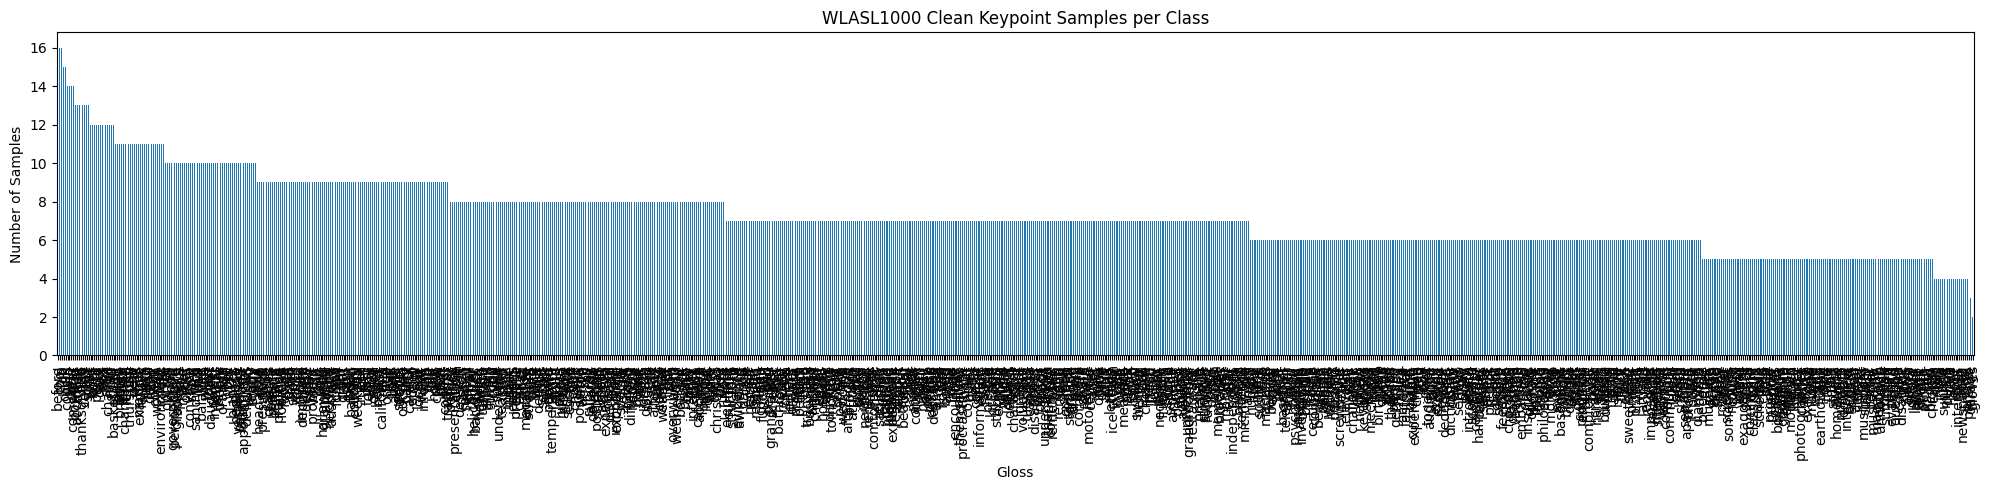

In [9]:
plt.figure(figsize=(20, 5))
class_counts.plot(kind="bar")
plt.title("WLASL1000 Clean Keypoint Samples per Class")
plt.xlabel("Gloss")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()